In [61]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_ollama import ChatOllama
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated, Literal
from operator import add

In [62]:
llm=ChatOllama(
    model="llama3.2:1b"
)

In [63]:
class RiskAnalyzerInput(TypedDict):
    text: str
    risk_score: int
    risk_level: str
    decision:str

In [89]:
def RiskAnalyzer(input: RiskAnalyzerInput) -> RiskAnalyzerInput:
    prompt = f"""
    You are a contract risk analyzer.

    Analyze the following contract.

    Return ONLY one integer between 0 and 100.

    Do not explain.
    Do not write sentences.
    Do not write markdown.

    Contract:
    {input["text"]}
    """
    response=llm.invoke(prompt).content.strip()

    response=int(response)
    if response < 40:
        risk_level = "low"
        
    elif response < 70:
        risk_level = "medium"
        

    else:
        risk_level = "high"
        

    return {
        "risk_score": response,
        "risk_level": risk_level,
    }

   


In [90]:
def route(input: RiskAnalyzerInput) -> RiskAnalyzerInput:
    if input["risk_level"] == "high":
        return "reject"
    else:
        return  "approve"

In [91]:
def auto_approve(input: RiskAnalyzerInput) -> RiskAnalyzerInput:
    return {"decision": "approve"}

In [92]:
def Human_Review(state: RiskAnalyzerInput) -> RiskAnalyzerInput:
    answer = interrupt(
        {
            "message": "High Risk Contract!",
            "risk_score": state["risk_score"],
            "risk_level": state["risk_level"],
            "text": state["text"],
            "question": "Do you want to Approve or Reject?"
        }
    )
    return {"decision": answer}


In [93]:
graph= StateGraph(RiskAnalyzerInput)

In [94]:
graph.add_node("RiskAnalyzer", RiskAnalyzer)
graph.add_node("auto_approve", auto_approve)
graph.add_node("Human_Review", Human_Review)
graph.add_edge(START, "RiskAnalyzer")
graph.add_conditional_edges("RiskAnalyzer", route,{"approve":"auto_approve","reject":"Human_Review"})
graph.add_edge("auto_approve", END)
graph.add_edge("Human_Review", END)

In [95]:
app=graph.compile(checkpointer=InMemorySaver())

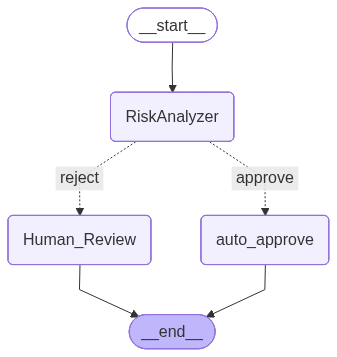

In [96]:
app

In [97]:
config = {
    "configurable": {
        "thread_id": "risk-1"
    }
}

In [101]:
app.invoke({"text": """The Company reserves the right to terminate this agreement at any time without prior notice or justification.
        """}, config=config)

{'text': 'The Company reserves the right to terminate this agreement at any time without prior notice or justification.\n        ',
 'risk_score': 90,
 'risk_level': 'high',
 'decision': 'Approved',
 '__interrupt__': [Interrupt(value={'message': 'High Risk Contract!', 'risk_score': 90, 'risk_level': 'high', 'text': 'The Company reserves the right to terminate this agreement at any time without prior notice or justification.\n        ', 'question': 'Do you want to Approve or Reject?'}, id='6c81687e8231c023f4e2007bc2660a3c')]}

In [102]:
app.invoke(Command(resume="reject"), config=config)

{'text': 'The Company reserves the right to terminate this agreement at any time without prior notice or justification.\n        ',
 'risk_score': 90,
 'risk_level': 'high',
 'decision': 'reject'}